# <span style='color:red'>Project 1: Dynamic Programming for Trade Scheduling</span>

In this project, we use dynamic programming to create a trading schedule that maximizes the total number of shares traded under a model of liquidity impact with memory.

The project has two computational goals:

1. first, develop a scalable **approximate** solution for the large problem;
2. then, solve the **same original integer-valued problem exactly** and compare the two approaches.


In [15]:
from IPython.display import display, HTML
display(HTML("<style>.container { width: 90% !important; }</style>"))

import csv
import sys
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import time


## Model

Suppose we have a total of $N$ shares that we would like to **attempt to trade** over $T$ time periods. We choose an order schedule
$$
(n_0,n_1,\ldots,n_{T-1}), \qquad n_i\in\mathbb Z_{\ge 0},
$$
subject to
$$
\sum_{i=0}^{T-1} n_i=N.
$$
Equivalently, in the final period we submit all shares that have not yet been scheduled:
$$
n_{T-1}=N-\sum_{i=0}^{T-2}n_i.
$$

The market does not necessarily allow the full submitted quantity to trade. We consider the following model. Let $M_{-1}=0$. Given parameters $\alpha>0$ and $0<\pi<1$, the process evolves as follows for $i=0,1,\ldots,T-1$:

1. After submitting $n_i$ shares, update the liquidity-memory
$$
M_i=\left\lceil \frac{M_{i-1}+n_i}{2}\right\rceil.
$$

2. The number of shares actually traded under this model in period $i$ is
$$
s_i=
\left\lceil
\bigl[1-\alpha M_i^\pi\bigr]_+\,n_i
\right\rceil,
\qquad [x]_+:=\max\{x,0\}.
$$

The objective is to choose the order schedule $(n_0,\ldots,n_{T-1})$ to maximize
$$
\sum_{i=0}^{T-1}s_i.
$$

**Notation:** $n_i$ denotes the submitted order size; $s_i$ denotes the model-implied traded quantity. We keep these two quantities distinct throughout the project.


### Example

Take
$$
N=10{,}000,\qquad T=4,\qquad \alpha=0.001,\qquad \pi=0.5,
$$
and consider the order schedule
$$
(5000,1000,2000,2000).
$$


In [16]:
def simulate_schedule(schedule, alpha, pi):
    """Simulate the liquidity-memory model for a given integer order schedule."""
    M = 0
    fills = []
    memory = []

    for n_i in schedule:
        n_i = int(n_i)
        M = math.ceil(0.5 * (M + n_i))
        traded = math.ceil(max(0.0, 1.0 - alpha * M**pi) * n_i)

        memory.append(M)
        fills.append(traded)

    return np.asarray(fills, dtype=int), np.asarray(memory, dtype=int)

N = 10_000
T = 4
alpha = 1e-3
pi = 0.5
schedule = np.array([5000, 1000, 2000, 2000], dtype=int)

assert schedule.sum() == N
fills, memory = simulate_schedule(schedule, alpha, pi)

for i in range(T):
    print(f"period {i}: order = {schedule[i]:5d}, M = {memory[i]:5d}, traded = {fills[i]:5d}")
print("total traded =", fills.sum())


period 0: order =  5000, M =  2500, traded =  4750
period 1: order =  1000, M =  1750, traded =   959
period 2: order =  2000, M =  1875, traded =  1914
period 3: order =  2000, M =  1938, traded =  1912
total traded = 9535


## <span style='color:red'>Task 1: Dynamic programming formulation and implementation</span>

Design a dynamic-programming algorithm that computes the optimal order schedule
$$
(n_0^*,n_1^*,\ldots,n_{T-1}^*)
$$
for the model above.

Before implementing your algorithm, clearly identify:

- the **state**;
- the **action** and feasible-action set;
- the **state transition**;
- the **one-period reward**;
- the **last-period condition**;
- the **Bellman recursion**.


## Task 1(a): Large-scale approximate DP

First, solve the large problem allowing numerical approximation.

You may use state-space discretization, interpolation, or other reasonable numerical approximations. You are also encouraged to use computational techniques such as vectorization and precomputation.

Your implementation should be designed to run in a reasonable amount of time for $N=100000$ and $T=10$.

**Requirements**

1. Clearly describe every approximation you use.
2. Report the approximate optimal schedule and the corresponding total number of shares traded.
3. Report the runtime of your implementation.
4. Perform at least one **refinement check**: make the approximation finer and report how the objective value and/or schedule changes.

There is no single required approximation method.

## Task 1(b): Exact DP

Now solve the **same problem exactly**.

For this part:

- do **not** discretize the state space;
- do **not** interpolate the value function;
- do **not** restrict the action space heuristically;
- your algorithm must optimize over the original integer-valued problem.

Your code should still run for
$$
N=100000,\qquad T=10,\qquad \alpha=0.001,\qquad \pi=0.5.
$$

Report:

1. the exact optimal schedule $(n_0^*,\ldots,n_9^*)$;
2. the exact optimal total number of shares traded;
3. runtime;
4. a measure of computational size, such as the number of states stored/processed at each period;
5. a comparison with your approximate solution from Task 1(a).

### Small hint
A dense table over every theoretically possible state is not necessarily the best representation.  
Think about whether a **forward DP** can keep only states that are actually reached as the algorithm progresses.






### Validation

Validate your exact implementation on at least one much smaller instance for which you can independently check the answer (for example, by brute-force enumeration or naive DP implementation).

Your exact DP and the independent calculation should return the same optimal objective value.

## <span style='color:red'>Task 1(b) Solution</span>

The forward DP from the lecture is exact, but for $N=100000$ it reaches about $2\cdot10^9$ states per period. We run the same DP and throw away every state that provably cannot lead to an optimal schedule, so the answer stays exact.

### Formulation

Let $S$ be the number of shares submitted so far and $R=N-S$ the number left.

- **State** before period $i$: $(S,M)$ with $M=M_{i-1}$, starting at $(0,0)$.
- **Action**: $n\in\{0,\ldots,N-S\}$, and $n=N-S$ in the last period.
- **Transition**: $(S,M)\to(S+n,M')$ with $M'=\lceil (M+n)/2\rceil$.
- **Reward**: $s(n,M')=\lceil[1-\alpha M'^\pi]_+\,n\rceil$.
- **Last period**: $V_{T-1}(R,M)=s\big(R,\lceil (M+R)/2\rceil\big)$.
- **Bellman**: $V_i(R,M)=\max_{0\le n\le R}\big[s(n,M')+V_{i+1}(R-n,M')\big]$, and the answer is $V_0(N,0)$.

Instead of the shares traded we count the shares lost, $\ell(n,M')=n-s(n,M')$. Since $\sum_i n_i=N$,
$$
\sum_i s_i=N-\sum_i \ell_i ,
$$
so maximizing what we trade is the same as minimizing the total loss. By induction $M_i=\lceil (M_{i-1}+n_i)/2\rceil\le\lceil (S_i+n_i)/2\rceil\le S_i+n_i\le N$, so $\alpha M_i^\pi\le\alpha N^\pi\approx0.32<1$ and $[\cdot]_+$ never clips. Using $\lceil n-y\rceil=n-\lfloor y\rfloor$ for an integer $n$,
$$
\ell(n,M')=\lfloor\alpha M'^\pi n\rfloor .
$$

We solve it forward. Let $F_i(S,M)$ be the smallest loss with which we can be at $(S,M)$ after $i$ periods. Then $F_0(0,0)=0$,
$$
F_{i+1}(S',M')=\min\Big\{F_i(S,M)+\ell(n,M')\ :\ S+n=S',\ \lceil (M+n)/2\rceil=M'\Big\},
$$
$$
\text{OPT}=\min_{(S,M)}\Big[F_{T-1}(S,M)+\ell\big(N-S,\lceil (M+N-S)/2\rceil\big)\Big],
$$
and we get the schedule by walking back from the best last state.

### Too many states

After 2 periods, for a fixed $S$ the memory can be anything from about $S/4$ to $S/2$, so we reach a constant fraction of all $N^2$ pairs. Counting them for small $N$ gives $0.13N^2$ states after 2 periods and $0.22N^2$ after 4. For $N=10^5$ that is $1$ to $2\cdot10^9$ states per period, each with up to $N$ actions. `brute` is exactly this DP; we only use it to check the fast version on small inputs.

In [17]:
from numba import njit, prange

INF = 1 << 30


def make_g(N, alpha, pi):
    return np.array([max(0.0, 1.0 - alpha * m**pi) for m in range(N + 1)])


@njit
def loss(n, m, g):
    return n - math.ceil(g[m] * n)


def brute(N, T, alpha, pi):
    dp = {(0, 0): 0}
    for i in range(T):
        ndp = {}
        for (s, m), f in dp.items():
            for n in ([N - s] if i == T - 1 else range(N - s + 1)):
                m2 = (m + n + 1) // 2
                f2 = f + n - math.ceil(max(0.0, 1.0 - alpha * m2**pi) * n)
                if f2 < ndp.get((s + n, m2), INF):
                    ndp[s + n, m2] = f2
        dp = ndp
    return N - min(dp.values())

### Dropping states

Let $V_k(R,M)$ be the smallest loss of the last $k$ periods if we start them with $R$ shares and memory $M$, and suppose we have a lower bound $B_k(R,M)\le V_k(R,M)$. Take a guess $U$ and keep a state after period $i$ only if
$$
F_i(S,M)+B_{T-i}(N-S,M)\le U .
$$
Every value the DP computes is the loss of an actual schedule, so if $U<\text{OPT}$ nothing survives until the end. Now let $U\ge\text{OPT}$ and take an optimal schedule with states $x_0,x_1,\ldots$, loss $P_i$ in its first $i$ periods and $Q_i$ in the rest, so $P_i+Q_i=\text{OPT}$ and $Q_i\ge B(x_i)$. If $x_i$ was kept with $F_i(x_i)\le P_i$, then
$$
F_{i+1}(x_{i+1})\le F_i(x_i)+\ell_i\le P_{i+1},\qquad
F_{i+1}(x_{i+1})+B(x_{i+1})\le P_{i+1}+Q_{i+1}=\text{OPT}\le U ,
$$
so $x_{i+1}$ is kept as well. By induction the whole optimal schedule survives, so the DP returns exactly OPT.

OPT is an integer and $\text{OPT}\ge B_T(N,0)$, so we try $U=\lceil B_T(N,0)\rceil,\ \lceil B_T(N,0)\rceil+1,\ldots$ and stop at the first $U$ that returns a schedule. That $U$ is OPT. The tries with a small $U$ throw away almost everything, so they are cheap.

### The lower bound

Start from $(R,M)$ with $k$ periods left and orders $n_1,\ldots,n_k$, and let $m_0=M$, $m_j=(m_{j-1}+n_j)/2$ be the memory without the ceilings. Then $M_j\ge m_j$, and since $\lfloor y\rfloor>y-1$,
$$
\ell_j=\lfloor\alpha M_j^\pi n_j\rfloor>\alpha m_j^\pi n_j-1 .
$$
Letting the orders be real numbers can only make the minimum smaller, so
$$
V_k(R,M)\ge\alpha\,C_k(R,M)-k,\qquad
C_k(R,M)=\min_{x_j\ge0,\ \sum_j x_j=R}\ \sum_{j=1}^k m_j^\pi x_j .
$$
If we multiply $R$, $M$ and every $x_j$ by $\lambda$, every $m_j$ is multiplied by $\lambda$ and every term by $\lambda^{1+\pi}$, so
$$
C_k(R,M)=R^{1+\pi}\varphi_k(M/R),\qquad \varphi_k(\rho)=C_k(1,\rho),
$$
and $\varphi_k$ depends only on $\rho=M/R$. Sending a fraction $x$ now gives memory $(\rho+x)/2$ and leaves $1-x$ shares, so the new ratio is $\rho'(x)=\frac{\rho+x}{2(1-x)}$ and
$$
\varphi_1(\rho)=\Big(\frac{\rho+1}{2}\Big)^\pi,\qquad
\varphi_k(\rho)=\min_{0\le x\le1}\Big[x\Big(\frac{\rho+x}{2}\Big)^\pi+(1-x)^{1+\pi}\varphi_{k-1}\big(\rho'(x)\big)\Big].
$$
A larger starting memory makes every $m_j$ larger, so $\varphi_k$ is nondecreasing. The last period has no choice, so there we use the exact loss:
$$
B_1(R,M)=\ell\big(R,\lceil (M+R)/2\rceil\big),\qquad
B_k(R,M)=\alpha R^{1+\pi}\varphi_k(M/R)-k\quad(k\ge2).
$$

### Computing $\varphi_k$

This is a 1-D version of the grid DP from 1(a), except that $B$ must never come out too big, so we never interpolate and always round down. We store $\varphi_k$ at $\rho_0=0$ and $\rho_p=10^{-4}e^{(p-1)h}$ with $h=5\cdot10^{-4}$, up to $10^4$, and read it at the largest grid point $\le\rho$. Since $\varphi_k$ is nondecreasing, this gives at most $\varphi_k(\rho)$.

For the minimum over $x$, take an interval $a\le x\le b$. The first term increases in $x$, $(1-x)^{1+\pi}$ decreases and $\rho'(x)$ increases, so for every $x$ in the interval
$$
x\Big(\frac{\rho+x}{2}\Big)^\pi+(1-x)^{1+\pi}\varphi_{k-1}\big(\rho'(x)\big)\ \ge\ a\Big(\frac{\rho+a}{2}\Big)^\pi+(1-b)^{1+\pi}\varphi_{k-1}\big(\rho'(a)\big).
$$
We split $[0,1]$ into 16 intervals and compute this lower value on each (with the table of $\varphi_{k-1}$, which is already rounded down). Going from the smallest lower value up, we split an interval into 16 again, 4 times (down to width $16^{-4}\approx1.5\cdot10^{-5}$), and skip it once its lower value is above the best value found so far. Every $x$ ends up in an interval whose lower value is at least the result, so the result is at most $\varphi_k(\rho_p)$. At the end we take a running max over $p$, which is fine since $\varphi_k$ is nondecreasing.

The tables depend only on $\pi$. Here $B_{10}(10^5,0)\approx9377.5$, so we start at $U=9378$.

In [18]:
H = 5e-4
RHO = np.concatenate(([0.0], 1e-4 * np.exp(H * np.arange(int(math.log(1e8) / H) + 1))))
P = len(RHO)


@njit
def pos(r):
    if r < RHO[1]:
        return 0
    p = min(int(math.log(r / RHO[1]) / H) + 1, P - 1)
    while RHO[p] > r:
        p -= 1
    while p + 1 < P and RHO[p + 1] <= r:
        p += 1
    return p


@njit
def low(rho, a, b, prv, pi):
    v = a * ((rho + a) / 2) ** pi
    if a < 1:
        v += (1 - b) ** (1 + pi) * prv[pos((rho + a) / (2 * (1 - a)))]
    return v


@njit
def zoom(rho, a, w, lvl, best, prv, pi):
    v = np.empty(16)
    for c in range(16):
        v[c] = low(rho, a + c * w, a + (c + 1) * w, prv, pi)
    for c in np.argsort(v):
        if v[c] >= best:
            break
        best = v[c] if lvl == 1 else zoom(rho, a + c * w, w / 16, lvl - 1, best, prv, pi)
    return best


@njit(parallel=True)
def next_phi(prv, pi):
    phi = np.empty(P)
    for p in prange(P):
        phi[p] = zoom(RHO[p], 0.0, 1 / 16, 4, np.inf, prv, pi)
    for p in range(1, P):
        phi[p] = max(phi[p], phi[p - 1])
    return phi


tables = {}

def get_phi(T, pi):
    if pi not in tables:
        tables[pi] = [np.zeros(P), ((RHO + 1) / 2) ** pi]
    while len(tables[pi]) <= T:
        tables[pi].append(next_phi(tables[pi][-1], pi))
    return np.array(tables[pi][:T + 1])


@njit
def bound(k, r, m, g, alpha, pi, phi):
    if r == 0:
        return 0.0
    if k == 1:
        return float(loss(r, (m + r + 1) // 2, g))
    return alpha * r ** (1 + pi) * phi[k, pos(m / r)] - k - 1e-6

### One period

Let $D=S-M$. An order $n$ from $(S,M)$ gives $S'=S+n$ and $M+n=S'-D$, so $M'=\lceil (S'-D)/2\rceil$, i.e.
$$
D=S'-2M'+e,\qquad n=2M'-e-M,\qquad e\in\{0,1\}.
$$
So every way into $(S',M')$ comes from row $D=S'-2M'$ or row $D=S'-2M'+1$, and on a row the memory $M$ fixes $n$. We store a period as `dp[D][M]` and get $F_{i+1}(S',M')$ by scanning two rows (a few thousand entries) instead of $N$ actions.

Before scanning we do a cheap check. Let $\beta=\alpha M'^\pi$, so $\ell(n,M')>\beta n-1$. If $f_D$ is the smallest value on row $D$ and $\bar M_D$ its largest $M$, then $n\ge2M'-e-\bar M_D$ and
$$
F_{i+1}(S',M')\ \ge\ \min_{e\in\{0,1\}}\Big[f_D+\beta\max\big(0,\,2M'-e-\bar M_D\big)-1\Big].
$$
If this plus $B$ is already above $U$, the state would be dropped anyway, so we don't scan. For the same reason we stop increasing $M'$ once $\min F_i+\beta\,(2M'-1-\max M)-1>U$, which only grows with $M'$.

`step` goes over the candidates twice: first only with the cheap check, to find out how big the next `dp` has to be, then with the exact scan.

In [19]:
@njit
def check(d2, m2, e, D0, dmin, dlast, beta):
    d = d2 - m2 + e - D0
    if d < 0 or d >= len(dmin) or dmin[d] == INF:
        return np.inf
    return dmin[d] + beta * max(0, 2 * m2 - e - dlast[d]) - 1


@njit
def pull(d2, m2, dp, D0, M0, first, last, g):
    best = INF
    for e in range(2):
        d = d2 - m2 + e - D0
        if d < 0 or d >= dp.shape[0]:
            continue
        for j in range(first[d], min(last[d], 2 * m2 - e - M0) + 1):
            if dp[d, j] < INF:
                best = min(best, dp[d, j] + loss(2 * m2 - e - M0 - j, m2, g))
    return best


@njit(parallel=True)
def step(dp, D0, M0, N, k, U, g, alpha, pi, phi):
    nD, nM = dp.shape
    dmin = np.full(nD, INF)
    first = np.full(nD, nM)
    last = np.full(nD, -1)
    for d in range(nD):
        for j in range(nM):
            if dp[d, j] < INF:
                dmin[d] = min(dmin[d], dp[d, j])
                first[d] = min(first[d], j)
                last[d] = j
    dlast = M0 + last
    fmin = dmin.min()
    c0 = c1 = (M0 + 1) // 2
    while c1 <= N and fmin + (1 - g[c1]) * max(0, 2 * c1 - 1 - (M0 + nM - 1)) - 1 <= U:
        c1 += 1

    lo = np.full(c1 - c0, INF)
    hi = np.full(c1 - c0, -1)
    for j in prange(c1 - c0):
        m2 = c0 + j
        beta = 1 - g[m2]
        for d2 in range(max(0, D0 + m2 - 1), D0 + nD + m2):
            if d2 + m2 > N:
                break
            q = min(check(d2, m2, 0, D0, dmin, dlast, beta), check(d2, m2, 1, D0, dmin, dlast, beta))
            if q + bound(k, N - d2 - m2, m2, g, alpha, pi, phi) <= U:
                lo[j] = min(lo[j], d2)
                hi[j] = max(hi[j], d2)

    js = np.nonzero(hi >= 0)[0]
    if len(js) == 0:
        return np.full((1, 1), INF, np.int32), 0, 0
    D1, M1 = lo.min(), c0 + js[0]
    ndp = np.full((hi.max() - D1 + 1, js[-1] - js[0] + 1), INF, np.int32)
    for j in prange(js[0], js[-1] + 1):
        m2 = c0 + j
        beta = 1 - g[m2]
        for d2 in range(lo[j], hi[j] + 1):
            B = bound(k, N - d2 - m2, m2, g, alpha, pi, phi)
            q = min(check(d2, m2, 0, D0, dmin, dlast, beta), check(d2, m2, 1, D0, dmin, dlast, beta))
            if q + B <= U:
                f = pull(d2, m2, dp, D0, M0, first, last, g)
                if f + B <= U:
                    ndp[d2 - D1, m2 - M1] = f
    return ndp, D1, M1


@njit
def finish(dp, D0, M0, N, g):
    ans, s, m = INF, -1, -1
    for d in range(dp.shape[0]):
        for j in range(dp.shape[1]):
            if dp[d, j] < INF:
                r = N - (D0 + d) - (M0 + j)
                f = dp[d, j] + loss(r, (M0 + j + r + 1) // 2, g)
                if f < ans:
                    ans, s, m = f, D0 + d + M0 + j, M0 + j
    return ans, s, m


@njit
def back(dp, D0, M0, s2, m2, f2, g):
    for e in range(2):
        d = s2 - 2 * m2 + e - D0
        if d < 0 or d >= dp.shape[0]:
            continue
        for j in range(dp.shape[1]):
            n = 2 * m2 - e - M0 - j
            if n >= 0 and dp[d, j] < INF and dp[d, j] + loss(n, m2, g) == f2:
                return n, M0 + j
    return -1, -1


def crop(dp, D0, M0):
    i, j = np.nonzero(dp < INF)
    return dp[i.min():i.max() + 1, j.min():j.max() + 1], D0 + i.min(), M0 + j.min()


def solve(N, T, alpha, pi, U, g, phi):
    lay = [(np.zeros((1, 1), np.int32), 0, 0)]
    for i in range(1, T):
        dp, D0, M0 = step(*lay[-1], N, T - i, U, g, alpha, pi, phi)
        if (dp == INF).all():
            return None
        lay.append(crop(dp, D0, M0))
    ans, s, m = finish(*lay[-1], N, g)
    if ans > U:
        return None
    sched = [N - s]
    for i in range(T - 1, 0, -1):
        dp, D0, M0 = lay[i]
        n, m2 = back(*lay[i - 1], s, m, dp[s - m - D0, m - M0], g)
        sched.append(int(n))
        s, m = s - n, m2
    return int(ans), sched[::-1], [int((dp < INF).sum()) for dp, _, _ in lay]


def exact(N, T, alpha, pi, verbose=True):
    assert alpha * N**pi < 1
    t0 = time.time()
    g, phi = make_g(N, alpha, pi), get_phi(T, pi)
    U = max(0, math.ceil(bound(T, N, 0, g, alpha, pi, phi)))
    while True:
        t = time.time()
        res = solve(N, T, alpha, pi, U, g, phi)
        if verbose:
            print(f"U = {U}: {'found ' + str(res[0]) if res else 'nothing'} ({time.time() - t:.1f}s)")
        if res:
            return res + (time.time() - t0,)
        U += 1

### Results for $N=100000$, $T=10$, $\alpha=0.001$, $\pi=0.5$

The time below includes compiling and building the $\varphi$ tables.

In [20]:
N, T, alpha, pi = 100000, 10, 1e-3, 0.5
ans, sched, states, sec = exact(N, T, alpha, pi)
fills, memory = simulate_schedule(sched, alpha, pi)
print("n* =", sched)
print("traded =", N - ans, "  simulate_schedule:", fills.sum())
print(f"time = {sec:.1f}s")
pd.DataFrame({'n': sched, 'M': memory, 's': fills, 'states kept': states}).rename_axis('period')

U = 9378: nothing (2.4s)
U = 9379: nothing (0.5s)
U = 9380: nothing (3.7s)
U = 9381: found 9381 (9.2s)
n* = [11666, 9779, 9120, 8949, 8686, 8842, 8887, 9330, 10389, 14352]
traded = 90619   simulate_schedule: 90619
time = 19.3s


,n,M,s,states kept
period,,,,
0,11666,5833,10776,1
1,9779,7806,8916,2083
2,9120,8463,8282,660010
3,8949,8706,8115,973459
4,8686,8696,7877,996807
5,8842,8769,8015,871131
6,8887,8828,8053,665511
7,9330,9079,8442,430174
8,10389,9734,9365,219651


1. Exact optimal schedule: $n^*=(11666,\ 9779,\ 9120,\ 8949,\ 8686,\ 8842,\ 8887,\ 9330,\ 10389,\ 14352)$.
2. Exact optimal total: $90619$ shares traded (loss $9381$), the same as `simulate_schedule`.
3. Runtime: about 50 s on 16 cores and about 2.5 minutes on 2 cores (Colab), including compiling and the $\varphi$ tables.
4. Size: the `states kept` column, at most about $10^6$ per period, against $1$ to $2\cdot10^9$ reached states for the plain DP. We tried $U=9378,9379,9380$ (nothing) and $U=9381$ (found), so OPT $=9381$.

### Comparison with 1(a)

The 1(a) schedules come from `task1a.py` (orders in multiples of $h$, value function interpolated in $M$), evaluated with the real simulator.

In [21]:
sol = {
    'equal split': [N // T] * T,
    '1(a) h=2000': [12000, 10000, 10000, 8000, 8000, 10000, 8000, 10000, 10000, 14000],
    '1(a) h=1000': [12000, 10000, 9000, 9000, 9000, 9000, 9000, 9000, 10000, 14000],
    '1(a) h=500': [11500, 10000, 9000, 9000, 9000, 9000, 9000, 9500, 10000, 14000],
    '1(a) h=250': [11750, 9500, 9500, 8750, 8750, 9000, 8750, 9500, 10500, 14000],
    '1(b) exact': sched,
}
df = pd.DataFrame({'traded': [simulate_schedule(v, alpha, pi)[0].sum() for v in sol.values()]}, index=list(sol))
df['gap'] = N - ans - df['traded']
df

,traded,gap
equal split,90556,63
1(a) h=2000,90605,14
1(a) h=1000,90614,5
1(a) h=500,90613,6
1(a) h=250,90616,3
1(b) exact,90619,0


The grid DP of 1(a) gets within 3 to 14 shares of the optimum and the equal split is 63 shares short. Making the grid finer helps but not every time ($h=500$ is worse than $h=1000$), because the interpolation can be off in either direction. The exact DP doesn't have this problem.

### Validation

We compare `exact` with `brute` on the 4 instances below plus 20 random ones ($N\le120$, $T\in\{2,3,4,5,6,10\}$, $\pi\in\{0.3,0.5,0.7\}$, random $\alpha$ with $\alpha N^\pi<1$), and also run every exact schedule through `simulate_schedule`. All three have to agree.

In [22]:
import random


def test(N, T, alpha, pi):
    ans, sched, _, _ = exact(N, T, alpha, pi, verbose=False)
    assert N - ans == brute(N, T, alpha, pi) == simulate_schedule(sched, alpha, pi)[0].sum()
    return N - ans


for t in [(60, 4, 0.05, 0.5), (200, 5, 0.02, 0.5), (300, 10, 0.03, 0.5), (150, 6, 0.04, 0.3)]:
    print(t, "->", test(*t))
random.seed(0)
for _ in range(20):
    n, p = random.randint(5, 120), random.choice([0.3, 0.5, 0.7])
    test(n, random.choice([2, 3, 4, 5, 6, 10]), random.uniform(0.2, 0.9) / n**p, p)
print("20 random tests ok")

(60, 4, 0.05, 0.5) -> 53
(200, 5, 0.02, 0.5) -> 182
(300, 10, 0.03, 0.5) -> 263
(150, 6, 0.04, 0.3) -> 140
20 random tests ok


# <span style='color:red'>Task 2: Evaluate the order schedule using TSLA volume data</span>

Use the **exact optimal schedule from Task 1(b)**,
$$
(n_0^*,n_1^*,\ldots,n_9^*).
$$



The file `TSLA.csv` contains 1-minute TSLA data. For each trading day, use the first two hours of regular trading, from 9:30 a.m. through 11:29 a.m. (Use the Volume column from the Trade block of the CSV, not the Bid or Ask blocks.)

Divide these 120 minutes into 12 consecutive 10-minute intervals.

For one 10-minute interval, let
$$
(V_0,V_1,\ldots,V_9)
$$
be the TSLA traded volumes in its ten one-minute bars.

The interval score is computed using:
$$
\boxed{
\text{Interval Score}
=
\sum_{i=0}^{9}\min\{n_i^*,V_i\}.
}
$$

The **TOTAL SCORE** is the average of the interval scores over the first 12 intervals of every day in the **first half of the dataset**.

For example, if the data contain 300 trading days, use the first 150 days and therefore $12\times150=1800$ intervals.

Using the schedule from Task 1(b):

1. Compute its TOTAL SCORE on the first half of the data.
2. Compare it with the TOTAL SCORE of the equal-sized schedule
$$
(N/T,\ldots,N/T).
$$







## <span style='color:red'>Task 3: Calibrate $\pi$ and evaluate out of sample</span>

Keep
$$
N=100{,}000,\qquad T=10,\qquad \alpha=0.001.
$$

Use the **first half of the data only** to choose $\pi$.

1. Search over values of $\pi$ in the interval
$$
[0.3,0.7].
$$
You may use a sufficiently fine grid or a coarse-to-fine search. State the values you evaluate.

2. For each candidate $\pi$:
   - use the exact DP algorithm from Task 1(b) to obtain an order schedule $n^*(\pi)$;
   - compute the training TOTAL SCORE of that schedule using Task 2.

3. Let $\pi^*$ be the value giving the highest training TOTAL SCORE. Report $\pi^*$, the corresponding schedule, and its training score. Plot TOTAL SCORE versus $\pi$ for the values you evaluated.

4. **Out-of-sample evaluation:** without changing $\pi^*$, compute the TOTAL SCORE of $n^*(\pi^*)$ on the second half of the trading days. Compare the training and out-of-sample scores.



### Part 3 solution

The original Task 1(b) cells and functions are unchanged.
The six cells below prepare the data, connect Part 2, call Task 1(b), search for π, plot the training scores, and evaluate the chosen schedule. NumPy array operations for the larger calculations.

### 3A. Prepare the volume data

CSV: select the Trade block, read its embedded headings, and parse its dates and volumes. Each complete morning becomes twelve ten-minute intervals. Split by trading day before calibration.

In [23]:
#Use the fixed Task 3 parameters.
p3_N, p3_T, p3_alpha = 100_000, 10, 0.001

#Read and clean the Trade section of the CSV using the Week 2 approach
#The dates and volumes below are the inputs for both data halves

#Read the provided CSV
p3_raw = pd.read_csv("TSLA.csv", low_memory=False)
#Select the Trade block, as in Week 2 Execution
p3_trade = p3_raw.iloc[:, :8].copy()
#Read the embedded column headings
p3_trade.columns = p3_trade.iloc[2].tolist()
#Remove headings and blank Trade rows
p3_trade = p3_trade.iloc[3:].dropna(subset=["Dates"]).copy()
#Parse the Trade timestamps
p3_trade["Dates"] = pd.to_datetime(p3_trade["Dates"], format="%m/%d/%y %H:%M")
#Convert the trade volumes to numbers
p3_trade["Volume"] = pd.to_numeric(p3_trade["Volume"])
#put the observations in time order
p3_trade = p3_trade.set_index("Dates").sort_index()
#prevent counting a minute twice
assert not p3_trade.index.duplicated().any(), "Duplicate Trade timestamps."
#chronological order list of trading days
p3_days = p3_trade.index.normalize().unique()
#keep the required two hours each day
p3_morning = p3_trade.between_time("09:30", "11:29")
#collect a volume array for each trading day
p3_daily = []

#handles one trading day at a time
#morning minutes are present, then stores their volumes in time order
#check each day before making the intervals
for p3_day in p3_days:
    #select this day's volumes
    p3_volume = p3_morning.loc[p3_morning.index.normalize() == p3_day, "Volume"]
    #list the required minutes
    p3_expected = pd.date_range(p3_day + pd.Timedelta(hours=9, minutes=30), periods=120, freq="min")
    #require all 120 minutes in order
    assert p3_volume.index.equals(p3_expected), "Incomplete morning data."
    #reject missing or negative volumes
    assert np.isfinite(p3_volume).all() and (p3_volume >= 0).all(), "Invalid volume."
    #check that volumes count whole shares
    assert np.equal(p3_volume, np.floor(p3_volume)).all(), "Non-integer volume."
    #store this day's checked volumes
    p3_daily.append(p3_volume.to_numpy(dtype=int))
#arrange the observations as days by minutes
p3_daily = np.array(p3_daily)

#split by whole trading days before creating 10 minute intervals
#keeps every day entirely in either the training or test half
#locate halfway point in trading days
p3_split = len(p3_days) // 2
#require nonempty training and test halves
assert 0 < p3_split < len(p3_days), "Both halves need trading days."
#make 10 minute rows from the first half
p3_csv_train = p3_daily[:p3_split].reshape(-1, p3_T)
#make 10 minute rows from the held out half
p3_csv_test = p3_daily[p3_split:].reshape(-1, p3_T)
#confirm data size
print("Training intervals:", len(p3_csv_train), "| Test intervals:", len(p3_csv_test))

Training intervals: 792 | Test intervals: 792


### 3B. Connect Part 2 and calculate TOTAL SCORE

The function uses NumPy to calculate all interval scores together and then takes their mean. The orders are the submitted orders, as specified in Task 2.

** Using training array, test array (if available), and scoring function. NOTE: Until task2 is ready, the defaults below work. Each array must have ten minute-volumes per row, in chronological order; a daily `(66, 120)` array can use `.reshape(-1, 10)`. The scoring function must accept `(schedule, interval_volumes)` and return the average score. If function takes volumes first, change the function call through a short named adapter; do not change original function.
The input comparisons check that the connected data follow the same split and interval definition.

In [24]:
#Use NumPy to compare all minute volumes with the corresponding orders at once
#sum across each interval, then average those sums to get TOTAL SCORE
#implement Task 2's score with NumPy array operations
def p3_score(schedule, interval_volumes):
    #sum min(order, volume) within each interval
    interval_scores = np.minimum(interval_volumes, schedule).sum(axis=1)
    #average the interval scores
    return float(interval_scores.mean())

### These three assignments are the connection to Part 2. ###
### Keep the current values until your teammate provides arrays and function ###

# CONNECT PART 2: replace the right side with training array when ready
p3_train = p3_csv_train
# CONNECT PART 2: replace the right side with test array if available
p3_test = p3_csv_test
# CONNECT PART 2: replace the right side with scoring function when ready
p3_total_score = p3_score
#check the training split and order
assert np.array_equal(p3_train, p3_csv_train), "Part 2 training data differ."
assert np.array_equal(p3_test, p3_csv_test), "Part 2 test data differ."

### 3C. Call the unchanged exact DP

When the original `exact` function accepts π, use it directly. For some larger π values its initial assertion fails, so the helper uses the same original `make_g`, `get_phi`, `bound`, and `solve` functions with a range check.

The range check now uses `np.arange` and array calculations, like the vectorized candidate calculations in Week 2 lecture DP. Checks every integer value of the total orders outside periods whose multiplier is clipped to zero. It uses Task 1(b)'s existing lower-bound expression and stops if that expression cannot certify the result. There is no new DP, action grid, or change to the original function.

In [25]:
#helper calls the existing Task 1(b) functions and checks their range
#reuse Task 1(b) for one candidate exponent
def p3_exact(candidate):
    #required parameter range
    assert 0.3 <= candidate <= 0.7
    #check original exact function's condition
    if p3_alpha * p3_N**candidate < 1:
        #call it unchanged when its condition holds
        return exact(p3_N, p3_T, p3_alpha, candidate, verbose=False)
    #time the call for a larger exponent
    started = time.perf_counter()
    #reuse the original fill multipliers
    g = make_g(p3_N, p3_alpha, candidate)
    #reuse the original bound tables
    phi = get_phi(p3_T, candidate)

    #for larger π, a period's fill multiplier can be clipped to zero
    #these NumPy calculations use Task 1(b)'s bound to check when such
    #schedules can be ruled out

    #consider every integer total outside clipped periods
    remaining = np.arange(p3_N + 1)
    #apply Task 1(b)'s bound expression to those orders
    other_loss = p3_alpha * remaining**(1 + candidate) * phi[p3_T - 1, 0] - (p3_T - 1) - 1e-6
    #lower bound the loss of any schedule containing clipping
    clipped_limit = np.min(p3_N - remaining + other_loss)
    #start at the original solver's loss cap
    cap = max(0, math.ceil(bound(p3_T, p3_N, 0, g, p3_alpha, candidate, phi)))

    #try original DP with a limit on total shares lost. If no schedule found, increase that limit by one
    #continue only while the range check certifies that the original pruning is safe
    #continue only while clipped schedules cannot meet the cap
    while cap < clipped_limit:
        #call the unchanged DP and schedule recovery
        result = solve(p3_N, p3_T, p3_alpha, candidate, cap, g, phi)
        #accept the complete schedule found by the DP
        if result is not None:
            #return the original result and elapsed time
            return result + (time.perf_counter() - started,)
        #increase the cap by one, as in the original exact function
        cap += 1
    #stop rather than claim an uncertified optimum
    raise RuntimeError("The range check cannot certify this candidate.")

### 3D. Search using only the training half

Using coarse-to-fine search, first evaluate `0.30, 0.35, ..., 0.70`. Then evaluate a grid within ±0.05 of the best coarse value, with spacing 0.01. Finally evaluate within ±0.01 of the current best value, with spacing 0.002. Keep every grid inside `[0.3, 0.7]`.

The lists store the tested exponents, schedules, and scores. A membership check skips previously evaluated exponents. Simple `if` statements keep the highest training score; ties choose the smaller π. The loop only organizes DP calls—the volume scoring and the large range-check calculation use NumPy.

In [26]:
#collect the evaluated candidates and their results
p3_values, p3_schedules, p3_scores = [], [], []
#start below every possible training score
p3_best_score = -np.inf
#center the first grid on the middle of the required range
p3_best_pi = 0.50
#time the full training search
p3_started = time.perf_counter()

#outer loop runs 3 stages: coarse, finer, then finest
#each new stage searches around the best training value found so far
#use the stated coarse grid and 2 refinements
for p3_width, p3_spacing in [(0.20, 0.05), (0.05, 0.01), (0.01, 0.002)]:
    #keep the next grid above the lower limit
    p3_low = max(0.30, p3_best_pi - p3_width)
    #keep the next grid below the upper limit
    p3_high = min(0.70, p3_best_pi + p3_width)
    #include both ends of the chosen grid
    p3_grid = np.arange(p3_low, p3_high + 0.0001, p3_spacing)

    #the inner loop obtains and scores each new candidate schedule
    #previously tested pi values are skipped, and only training data are used

    #solve each candidate in this stage
    for p3_value in p3_grid:
        #remove insignificant floating-point differences in the grid
        p3_candidate = round(float(p3_value), 3)
        #check whether an earlier stage already evaluated this value
        if p3_candidate in p3_values:
            #avoid repeating a completed DP solve
            continue
        #obtain the exact schedule using Task 1(b)
        p3_loss, p3_orders, _, p3_seconds = p3_exact(p3_candidate)
        #replay the returned schedule.
        p3_fills, _ = simulate_schedule(p3_orders, p3_alpha, p3_candidate)
        #check schedule feasibility
        assert len(p3_orders) == p3_T and sum(p3_orders) == p3_N and min(p3_orders) >= 0
        #check that the schedule attains the DP objective
        assert int(p3_fills.sum()) == p3_N - p3_loss
        #use only training volumes to rank this candidate
        p3_score_value = p3_total_score(p3_orders, p3_train)
        #verify any connected Part 2 function
        assert np.isclose(p3_score_value, p3_score(p3_orders, p3_train), rtol=0, atol=1e-8)
        #record the evaluated exponent
        p3_values.append(p3_candidate)
        #record its submitted orders
        p3_schedules.append(p3_orders)
        #record its training score
        p3_scores.append(p3_score_value)

        #keep the candidate with the highest training score. If a tie, choose smaller pi. 
        #save its matching schedule for the later test evaluation
        #select by training score, breaking ties by smaller pi
        if p3_score_value > p3_best_score or (p3_score_value == p3_best_score and p3_candidate < p3_best_pi):
            #update the highest training score
            p3_best_score = p3_score_value
            #update the selected exponent
            p3_best_pi = p3_candidate
            #keep its orders for the final test evaluation
            p3_best_schedule = np.array(p3_orders, dtype=int)
        #print progress
        print(f"pi = {p3_candidate:.3f}; training score = {p3_score_value:,.3f}; time = {p3_seconds:.1f} s", flush=True)
#record search runtime
p3_search_seconds = time.perf_counter() - p3_started
#sort evaluated candidates for reporting
p3_results = pd.DataFrame({"pi": p3_values, "training_score": p3_scores}).sort_values("pi").reset_index(drop=True)
#state every evaluated exponent and its training score
display(p3_results.round(3))
#print selected exponent and orders
print(f"Selected pi = {p3_best_pi:.3f}; schedule = {p3_best_schedule.tolist()}")
#print measured calibration time
print(f"Search time: {p3_search_seconds / 60:.2f} minutes.")

pi = 0.300; training score = 99,824.365; time = 59.2 s
pi = 0.350; training score = 99,841.895; time = 35.9 s
pi = 0.400; training score = 99,849.561; time = 35.6 s
pi = 0.450; training score = 99,863.938; time = 24.2 s
pi = 0.500; training score = 99,878.139; time = 12.0 s
pi = 0.550; training score = 99,881.615; time = 18.2 s
pi = 0.600; training score = 99,890.746; time = 15.7 s
pi = 0.650; training score = 99,892.225; time = 21.2 s
pi = 0.700; training score = 99,894.481; time = 28.4 s
pi = 0.660; training score = 99,890.870; time = 24.9 s
pi = 0.670; training score = 99,891.125; time = 27.3 s
pi = 0.680; training score = 99,893.537; time = 25.3 s
pi = 0.690; training score = 99,892.857; time = 29.9 s
pi = 0.692; training score = 99,895.466; time = 27.6 s
pi = 0.694; training score = 99,893.102; time = 30.9 s
pi = 0.696; training score = 99,895.013; time = 29.0 s
pi = 0.698; training score = 99,895.862; time = 29.7 s


,pi,training_score
0,0.300,99824.365
1,0.350,99841.895
2,0.400,99849.561
3,0.450,99863.938
4,0.500,99878.139
5,0.550,99881.615
6,0.600,99890.746
7,0.650,99892.225
8,0.660,99890.870
9,0.670,99891.125


Selected pi = 0.698; schedule = [12220, 9968, 9147, 8947, 8876, 8913, 8926, 9245, 10175, 13583]
Search time: 7.92 minutes.


### 3E. Plot the training scores

TOTAL SCORE-versus-π plot. The star marks the highest training score among the evaluated values. The vertical scale focuses on the small differences; exact scores are in the preceding table

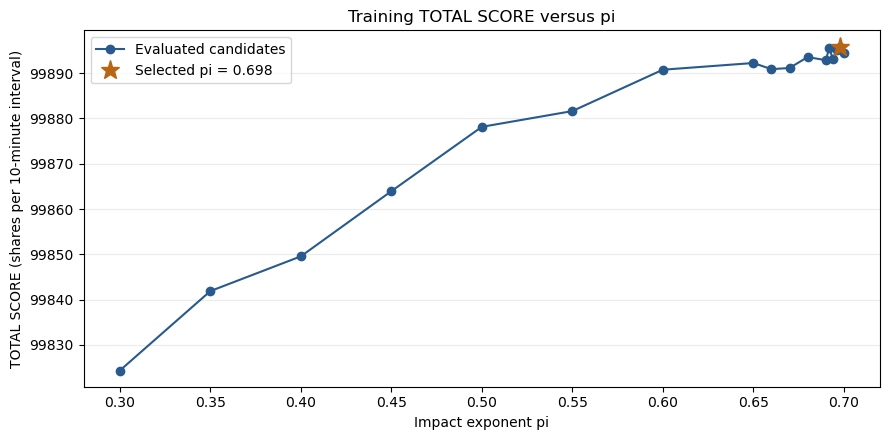

In [27]:
#plot the training scores used to choose π
#the star identifies the selected value among the tested candidates

plt.figure(figsize=(9, 4.5))
#plot training scores
plt.plot(p3_results["pi"], p3_results["training_score"], "o-", color="#285A8E", label="Evaluated candidates")
#mark selected value
plt.plot(p3_best_pi, p3_best_score, "*", color="#B86613", markersize=14, label=f"Selected pi = {p3_best_pi:.3f}")
plt.xlabel("Impact exponent pi")
plt.ylabel("TOTAL SCORE (shares per 10-minute interval)")
plt.title("Training TOTAL SCORE versus pi")
#compare nearby score values
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### 3F. Evaluate the fixed schedule on the second half

Keep both the chosen exponent and schedule fixed. Compare their training and test TOTAL SCORE using the same definition; do not recalibrate on the test data.

In [28]:
#use same selected schedule on both data halves
#keep π and orders fixed so test data do not affect calibration
#score chosen orders on training data
p3_train_score = p3_total_score(p3_best_schedule, p3_train)
#score same orders on held out data
p3_test_score = p3_total_score(p3_best_schedule, p3_test)
#verify any connected Part 2 test calculation
assert np.isclose(p3_test_score, p3_score(p3_best_schedule, p3_test), rtol=0, atol=1e-8)
#make the comparison table
p3_comparison = pd.DataFrame({"Data half": ["Training", "Test"], "TOTAL SCORE": [p3_train_score, p3_test_score]})
#display both averages in the same units
display(p3_comparison.round(3))
#calculate the out of sample change
p3_difference = p3_test_score - p3_train_score
#quantify difference.
print(f"Test minus training: {p3_difference:+.3f} shares per interval ({100 * p3_difference / p3_train_score:+.4f}%).")

,Data half,TOTAL SCORE
0,Training,99895.862
1,Test,99878.664


Test minus training: -17.198 shares per interval (-0.0172%).


### Part 3 results

The coarse-to-fine search evaluated **17 values** of $\pi$, listed in the table in 3D. The best evaluated training value was **$\pi^*=0.698$**, with submitted order schedule

`[12220, 9968, 9147, 8947, 8876, 8913, 8926, 9245, 10175, 13583]`

The schedule contains ten nonnegative integer orders and totals 100,000 shares. Its training TOTAL SCORE was **99,895.862 shares per ten-minute interval**.

With both the exponent and schedule held fixed, the second-half TOTAL SCORE was **99,878.664 shares per ten-minute interval**. This is **17.198 shares lower** than training, a change of **-0.0172%**. The observed scores are close on these two halves; this comparison alone does not establish performance on other datasets.

Training used the first 66 trading days (2021-01-04 through 2021-04-08), and testing used the remaining 66 (2021-04-09 through 2021-07-13). Each half contained 792 ten-minute intervals. Test scores were not used to select the exponent or schedule.

This run took **10.50 minutes** for calibration. Runtime depends on the computer and whether Numba has already compiled the original Task 1(b) functions. The search solves the original integer DP for every evaluated candidate; it does not establish a maximum over every real $\pi$ in $[0.3,0.7]$.